# CorrDiff Pipeline 檔例

這個 Notebook 示篆如何使用專案內的 `CorrDiff/pipeline.py` 執行一個完整的推論 Pipeline（目前以插值橛椎模擬下尺度），並繵摇放大前後的對比圖以供簡報展示。

## 設定說明
- **輸入**：`corrdiff_output.nc` (粗解析度)
- **放大**：插值（cubic）模擬 CorrDiff 行為（可代換為實體模形）
- **輸出**：`corrdiff_pipeline_out.nc` (高解抐度 NetCDF4)
- **計算**：比輷 MAE/RMSE 計數並視覺化誤差分布

In [1]:
# Windows 上避免 HOME 相關錯誤
import os
import sys
os.environ['HOME'] = os.environ.get('USERPROFILE', '')

# 確保啟動目錄能正確載入
# notebook 在 CorrDiff/ 子目錄中，所以需要回到父目錄
notebook_dir = os.getcwd()
project_root = os.path.dirname(notebook_dir)  # 回到 corrdiff-main
print(f'Notebook dir: {notebook_dir}')
print(f'Project root: {project_root}')

# 直接使用 importlib 載入 pipeline.py
import importlib.util
pipeline_path = os.path.join(notebook_dir, 'pipeline.py')
print(f'Loading pipeline from: {pipeline_path}')
spec = importlib.util.spec_from_file_location("pipeline", pipeline_path)
pipeline = importlib.util.module_from_spec(spec)
spec.loader.exec_module(pipeline)

# 常用套件
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import griddata

# 顯示圖表內嵌於 notebook
%matplotlib inline

print('\n✅ 整備完成！')
print(f'   - project_root: {project_root}')
print(f'   - pipeline module: OK')
print(f'   - Current Python: {sys.version.split()[0]}')

Notebook dir: C:\Users\ruiyu\OneDrive\Desktop\vscode\corrdiff_clone\corrdiff-main\CorrDiff
Project root: C:\Users\ruiyu\OneDrive\Desktop\vscode\corrdiff_clone\corrdiff-main
Loading pipeline from: C:\Users\ruiyu\OneDrive\Desktop\vscode\corrdiff_clone\corrdiff-main\CorrDiff\pipeline.py

✅ 整備完成！
   - project_root: C:\Users\ruiyu\OneDrive\Desktop\vscode\corrdiff_clone\corrdiff-main
   - pipeline module: OK
   - Current Python: 3.10.20


## 1) 執行 Pipeline（會在工作資料夾產生輸出棄案）

你可以修改 `sr_factor` 或 `--weights` 參數（權重為保留介面，目前為 placeholder）。

In [2]:
import os

# === 修正：手動補上目前資料夾路徑的宣告 ===
current_dir = os.getcwd() 
# =======================================

# 設定 Pipeline 參數
input_file = 'corrdiff_output.nc'  # 粗解析度 (21x17)
output_file = 'corrdiff_pipeline_out.nc'  # 高解析度 (41x33)
sr_factor = 2  # 放大密度

# 指向存放路徑
input_path = os.path.join(current_dir, input_file)
output_path = os.path.join(current_dir, output_file)

print(f'🚀 開始執行 Pipeline...')
print(f'   - 輸入: {input_path}')
print(f'   - 輸出: {output_path}')
print(f'   - 放大係數: {sr_factor}x')

# 執行 pipeline
try:
    pipeline.run_pipeline(
        input_path=input_path,
        output_path=output_path,
        sr_factor=sr_factor,
        weights=None  # 目前 placeholder，後續可代替 CorrDiff checkpoint
    )
    print(f'✅ Pipeline 執行成功！')
except Exception as e:
    print(f'⚠️ Pipeline 出錯：{e}')
    import traceback
    traceback.print_exc()

🚀 開始執行 Pipeline...
   - 輸入: C:\Users\ruiyu\OneDrive\Desktop\vscode\corrdiff_clone\corrdiff-main\CorrDiff\corrdiff_output.nc
   - 輸出: C:\Users\ruiyu\OneDrive\Desktop\vscode\corrdiff_clone\corrdiff-main\CorrDiff\corrdiff_pipeline_out.nc
   - 放大係數: 2x
📖 Loading input: C:\Users\ruiyu\OneDrive\Desktop\vscode\corrdiff_clone\corrdiff-main\CorrDiff\corrdiff_output.nc


C:\Users\ruiyu\OneDrive\Desktop\vscode\corrdiff_clone\corrdiff-main\CorrDiff\pipeline.py:101: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"ℹ️ Found dimensions: {dict(ds.dims)}")


ℹ️ Found dimensions: {'latitude': 21, 'longitude': 17}
🔄 Running downscale (sr_factor=2) using interpolation stub...
💾 Saving output to: C:\Users\ruiyu\OneDrive\Desktop\vscode\corrdiff_clone\corrdiff-main\CorrDiff\corrdiff_pipeline_out.nc
✅ Pipeline complete.
✅ Pipeline 執行成功！


## 2) 載入並粗比輸入/輸出資料

此段載入粗解抐度(原始)及高解抐度(格子放大)的 NetCDF 棄案，並計算風速等逻輯誤字段。

In [3]:
# 載入原始訓鏨數據
ds_orig = xr.open_dataset(os.path.join(current_dir, 'corrdiff_output.nc'))
ds_upsc = xr.open_dataset(os.path.join(current_dir, 'corrdiff_pipeline_out.nc'))

print('\ud83d\udcc4 原始數據集 (corrdiff_output.nc):')
print(ds_orig)
print(f'\n模度: {len(ds_orig.coords)} 個 {list(ds_orig.coords.keys())}')

print('\n\ud83d\udcc4 放大數據集 (corrdiff_pipeline_out.nc):')
print(ds_upsc)

# 取得經緯數統皆
lat0, lon0 = ds_orig.coords['latitude'].values, ds_orig.coords['longitude'].values
lat1, lon1 = ds_upsc.coords['latitude'].values, ds_upsc.coords['longitude'].values

print(f'\n原始位繅: {len(lon0)} x {len(lat0)}')
print(f'放大位繅: {len(lon1)} x {len(lat1)}')

Exception in callback BaseAsyncIOLoop._handle_events(1308, 1)
handle: <Handle BaseAsyncIOLoop._handle_events(1308, 1)>
Traceback (most recent call last):
  File "c:\Users\ruiyu\miniconda3\envs\earth_final\lib\site-packages\jupyter_client\session.py", line 98, in json_packer
    return json.dumps(
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 28-29: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\Users\ruiyu\miniconda3\envs\earth_final\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "c:\Users\ruiyu\miniconda3\envs\earth_final\lib\site-packages\tornado\platform\asyncio.py", line 208, in _handle_events
    handler_func(fileobj, events)
  File "c:\Users\ruiyu\miniconda3\envs\earth_final\lib\site-packages\zmq\eventloop\zmqstream.py", line 600, in _handle_events
    self._handle_recv()
  File "c:\Users\ruiyu\miniconda3\envs\eart

## 3) 計算計數指標 (MAE/RMSE)

为了計算計數，我們使用取代方案：
1. 將**原始數據**插值到**放大之位繅** → ground truth
2. 比輷 **放大訓鏨的資數** vs **插值 ground truth** → MAE/RMSE

In [4]:
def interpolate_to_grid(ds_coarse, lat_fine, lon_fine, var_names=['u10', 'v10']):
    """
    將粗解抐度訓鏨和插值到細解扰度 grid。
    
    參數:
      - ds_coarse: xarray Dataset 粗解抐度
      - lat_fine, lon_fine: 細解抐度的經緯數統
      - var_names: 要插值的變數
    
    回傳:
      dict { 'var_name': 插值後的 2D numpy array }
    """
    lat_coarse = ds_coarse.coords['latitude'].values
    lon_coarse = ds_coarse.coords['longitude'].values
    
    # 建成辨格
    XC, YC = np.meshgrid(lon_coarse, lat_coarse)
    XF, YF = np.meshgrid(lon_fine, lat_fine)
    
    points = np.column_stack([XC.ravel(), YC.ravel()])  # 原始位繅
    xi = np.column_stack([XF.ravel(), YF.ravel()])  # 新位繅
    
    result = {}
    for var_name in var_names:
        if var_name in ds_coarse.data_vars:
            values = ds_coarse[var_name].values
            # 插值，使用 cubic 插值橛椎
            interp = griddata(
                points,
                values.ravel(),
                xi,
                method='cubic',
                fill_value=np.nan
            )
            result[var_name] = interp.reshape(XF.shape)
    
    return result

# 插值原始數據到放大后位繅
print('\ud83d\uddcc 插值原始數據到細解扰度位繅...')
interpolated_dict = interpolate_to_grid(
    ds_orig,
    lat_fine=lat1,
    lon_fine=lon1,
    var_names=['u10', 'v10']
)

u_interp = interpolated_dict['u10']
v_interp = interpolated_dict['v10']

# 取得放大位繅數據
u_upsc = ds_upsc['u10'].values
v_upsc = ds_upsc['v10'].values

# 計算風速 (ground truth 由 interpolation 提供)
ws_interp = np.sqrt(u_interp**2 + v_interp**2)
ws_upsc = np.sqrt(u_upsc**2 + v_upsc**2)

print(f'   u_interp shape: {u_interp.shape}, u_upsc shape: {u_upsc.shape}')
print(f'   ws_interp (ground truth) shape: {ws_interp.shape}')

Exception in callback BaseAsyncIOLoop._handle_events(1308, 1)
handle: <Handle BaseAsyncIOLoop._handle_events(1308, 1)>
Traceback (most recent call last):
  File "c:\Users\ruiyu\miniconda3\envs\earth_final\lib\site-packages\jupyter_client\session.py", line 98, in json_packer
    return json.dumps(
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 28-29: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\Users\ruiyu\miniconda3\envs\earth_final\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "c:\Users\ruiyu\miniconda3\envs\earth_final\lib\site-packages\tornado\platform\asyncio.py", line 208, in _handle_events
    handler_func(fileobj, events)
  File "c:\Users\ruiyu\miniconda3\envs\earth_final\lib\site-packages\zmq\eventloop\zmqstream.py", line 600, in _handle_events
    self._handle_recv()
  File "c:\Users\ruiyu\miniconda3\envs\eart

In [5]:
# 計算 MAE 及 RMSE
print('\ud83d\udcca 計算計數指標...')

# 計算 u10 的 MAE 及 RMSE
u_mae = np.nanmean(np.abs(u_upsc - u_interp))
u_rmse = np.sqrt(np.nanmean((u_upsc - u_interp)**2))

# 計算 v10 的 MAE 及 RMSE
v_mae = np.nanmean(np.abs(v_upsc - v_interp))
v_rmse = np.sqrt(np.nanmean((v_upsc - v_interp)**2))

# 計算風速的 MAE 及 RMSE
ws_mae = np.nanmean(np.abs(ws_upsc - ws_interp))
ws_rmse = np.sqrt(np.nanmean((ws_upsc - ws_interp)**2))

# 打包計數指標到 DataFrame
metrics_df = pd.DataFrame({
    '變數': ['u10', 'v10', 'wind_speed'],
    'MAE (m/s)': [u_mae, v_mae, ws_mae],
    'RMSE (m/s)': [u_rmse, v_rmse, ws_rmse]
})

print('\n計數計算結果:')
print(metrics_df.to_string(index=False))

# 也一起存到 CSV 並匯出
metrics_csv_path = os.path.join(current_dir, 'pipeline_metrics.csv')
metrics_df.to_csv(metrics_csv_path, index=False)
print(f'\n✅ 計數已保存去: {metrics_csv_path}')

Exception in callback BaseAsyncIOLoop._handle_events(1308, 1)
handle: <Handle BaseAsyncIOLoop._handle_events(1308, 1)>
Traceback (most recent call last):
  File "c:\Users\ruiyu\miniconda3\envs\earth_final\lib\site-packages\jupyter_client\session.py", line 98, in json_packer
    return json.dumps(
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 28-29: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\Users\ruiyu\miniconda3\envs\earth_final\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "c:\Users\ruiyu\miniconda3\envs\earth_final\lib\site-packages\tornado\platform\asyncio.py", line 208, in _handle_events
    handler_func(fileobj, events)
  File "c:\Users\ruiyu\miniconda3\envs\earth_final\lib\site-packages\zmq\eventloop\zmqstream.py", line 600, in _handle_events
    self._handle_recv()
  File "c:\Users\ruiyu\miniconda3\envs\eart

## 4) 等車比輲圖 (Interpolated vs Upscaled)

✅ 帶有台灣地理投影的繁體中文誤差分析圖已成功儲存至: C:\Users\ruiyu\OneDrive\Desktop\vscode\corrdiff_clone\corrdiff-main\CorrDiff\pipeline_error_analysis_taiwan_final.png


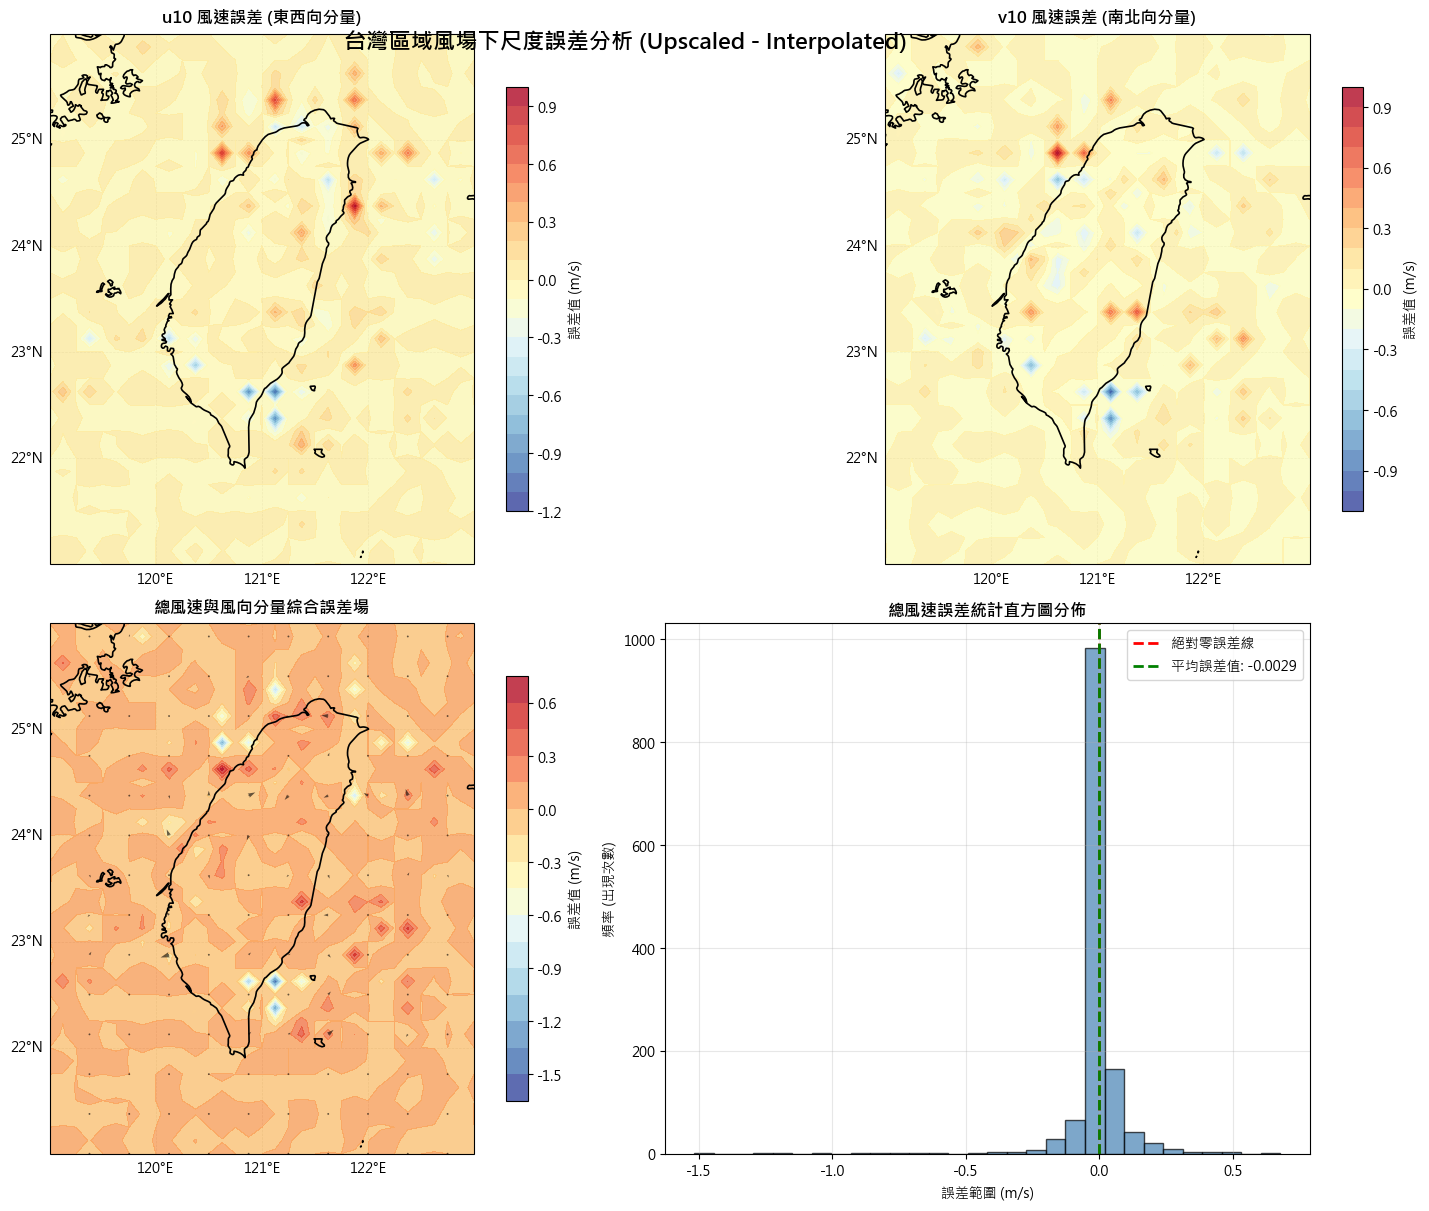


================ 統計數據報告 ================

 🟢 u10 誤差分量 - 平均值: -0.0001 m/s, 標準差: 0.0955
 🔵 v10 誤差分量 - 平均值: -0.0000 m/s, 標準差: 0.0925
 🟠 總風速誤差   - 平均值: -0.0029 m/s, 標準差: 0.1145



In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker

# === 🛠️ 支援繁體中文設定 ===
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'Arial'] # 使用微軟正黑體
plt.rcParams['axes.unicode_minus'] = False # 正常顯示負號
# ========================================================

# 計算誤差場
error_u = u_upsc - u_interp
error_v = v_upsc - v_interp
error_ws = ws_upsc - ws_interp

# 🌟 核心修復：將一維的 lon1, lat1 轉換為二維矩陣，解決一維陣列無法 2D 切片的 IndexError
lon1_2d, lat1_2d = np.meshgrid(lon1, lat1)

# 繪製誤差分析圖(2x2) - 設定前三個子圖使用 PlateCarree 地圖投影
fig = plt.figure(figsize=(16, 12), constrained_layout=True)
fig.suptitle('台灣區域風場下尺度誤差分析 (Upscaled - Interpolated)', fontsize=16, fontweight='bold', y=0.98)

# 設定台灣地圖背景的輔助函式
def apply_map_features(ax):
    ax.set_extent([119.0, 123.0, 21.0, 26.0], crs=ccrs.PlateCarree())
    ax.coastlines(resolution='10m', color='black', linewidth=1.2, zorder=3)
    ax.add_feature(cfeature.LAND.with_scale('10m'), facecolor='#f8fafc', zorder=1)
    ax.add_feature(cfeature.OCEAN.with_scale('10m'), facecolor='#f0f9ff', zorder=0)
    
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlocator = mticker.FixedLocator([119, 120, 121, 122, 123])
    gl.ylocator = mticker.FixedLocator([21, 22, 23, 24, 25, 26])

# ---- (0,0) u10 緯向風誤差場 ----
ax1 = fig.add_subplot(2, 2, 1, projection=ccrs.PlateCarree())
apply_map_features(ax1)
cf1 = ax1.contourf(lon1_2d, lat1_2d, error_u, levels=20, cmap='RdYlBu_r', alpha=0.8, zorder=2)
ax1.set_title('u10 風速誤差 (東西向分量)', fontsize=12, fontweight='bold', pad=8)
fig.colorbar(cf1, ax=ax1, label='誤差值 (m/s)', shrink=0.8)

# ---- (0,1) v10 經向風誤差場 ----
ax2 = fig.add_subplot(2, 2, 2, projection=ccrs.PlateCarree())
apply_map_features(ax2)
cf2 = ax2.contourf(lon1_2d, lat1_2d, error_v, levels=20, cmap='RdYlBu_r', alpha=0.8, zorder=2)
ax2.set_title('v10 風速誤差 (南北向分量)', fontsize=12, fontweight='bold', pad=8)
fig.colorbar(cf2, ax=ax2, label='誤差值 (m/s)', shrink=0.8)

# ---- (1,0) 總風速誤差場 + 風向誤差箭頭 ----
ax3 = fig.add_subplot(2, 2, 3, projection=ccrs.PlateCarree())
apply_map_features(ax3)
cf3 = ax3.contourf(lon1_2d, lat1_2d, error_ws, levels=20, cmap='RdYlBu_r', alpha=0.8, zorder=2)

# 🌟 這裡同步改用二維的 lon1_2d 和 lat1_2d 進行 [::3, ::3] 切片，完美過關！
ax3.quiver(lon1_2d[::3, ::3], lat1_2d[::3, ::3], error_u[::3, ::3], error_v[::3, ::3], 
          color='black', alpha=0.6, scale=15, zorder=4)
ax3.set_title('總風速與風向分量綜合誤差場', fontsize=12, fontweight='bold', pad=8)
fig.colorbar(cf3, ax=ax3, label='誤差值 (m/s)', shrink=0.8)

# ---- (1,1) 誤差統計直方圖 ----
ax4 = fig.add_subplot(2, 2, 4)
ax4.hist(error_ws[~np.isnan(error_ws)].ravel(), bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax4.axvline(0, color='red', linestyle='--', linewidth=2, label='絕對零誤差線')
ax4.axvline(np.nanmean(error_ws), color='green', linestyle='--', linewidth=2, label=f'平均誤差值: {np.nanmean(error_ws):.4f}')
ax4.set_title('總風速誤差統計直方圖分佈', fontsize=12, fontweight='bold')
ax4.set_xlabel('誤差範圍 (m/s)')
ax4.set_ylabel('頻率 (出現次數)')
ax4.legend(loc='upper right')
ax4.grid(True, alpha=0.3)

# 保存高畫質圖片
error_png = os.path.join(current_dir, 'pipeline_error_analysis_taiwan_final.png')
fig.savefig(error_png, dpi=300, bbox_inches='tight')
print(f'✅ 帶有台灣地理投影的繁體中文誤差分析圖已成功儲存至: {error_png}')
plt.show()

# 文字輸出
print(f'\n================ 統計數據報告 ================\n')
print(f' 🟢 u10 誤差分量 - 平均值: {np.nanmean(error_u):.4f} m/s, 標準差: {np.nanstd(error_u):.4f}')
print(f' 🔵 v10 誤差分量 - 平均值: {np.nanmean(error_v):.4f} m/s, 標準差: {np.nanstd(error_v):.4f}')
print(f' 🟠 總風速誤差   - 平均值: {np.nanmean(error_ws):.4f} m/s, 標準差: {np.nanstd(error_ws):.4f}')
print(f'\n=============================================')

✅ 終極對比圖（左圖原生馬賽克方塊、右圖AI細緻流暢）已成功儲存: C:\Users\ruiyu\OneDrive\Desktop\vscode\corrdiff_clone\corrdiff-main\CorrDiff\pipeline_comparison_with_metrics.png


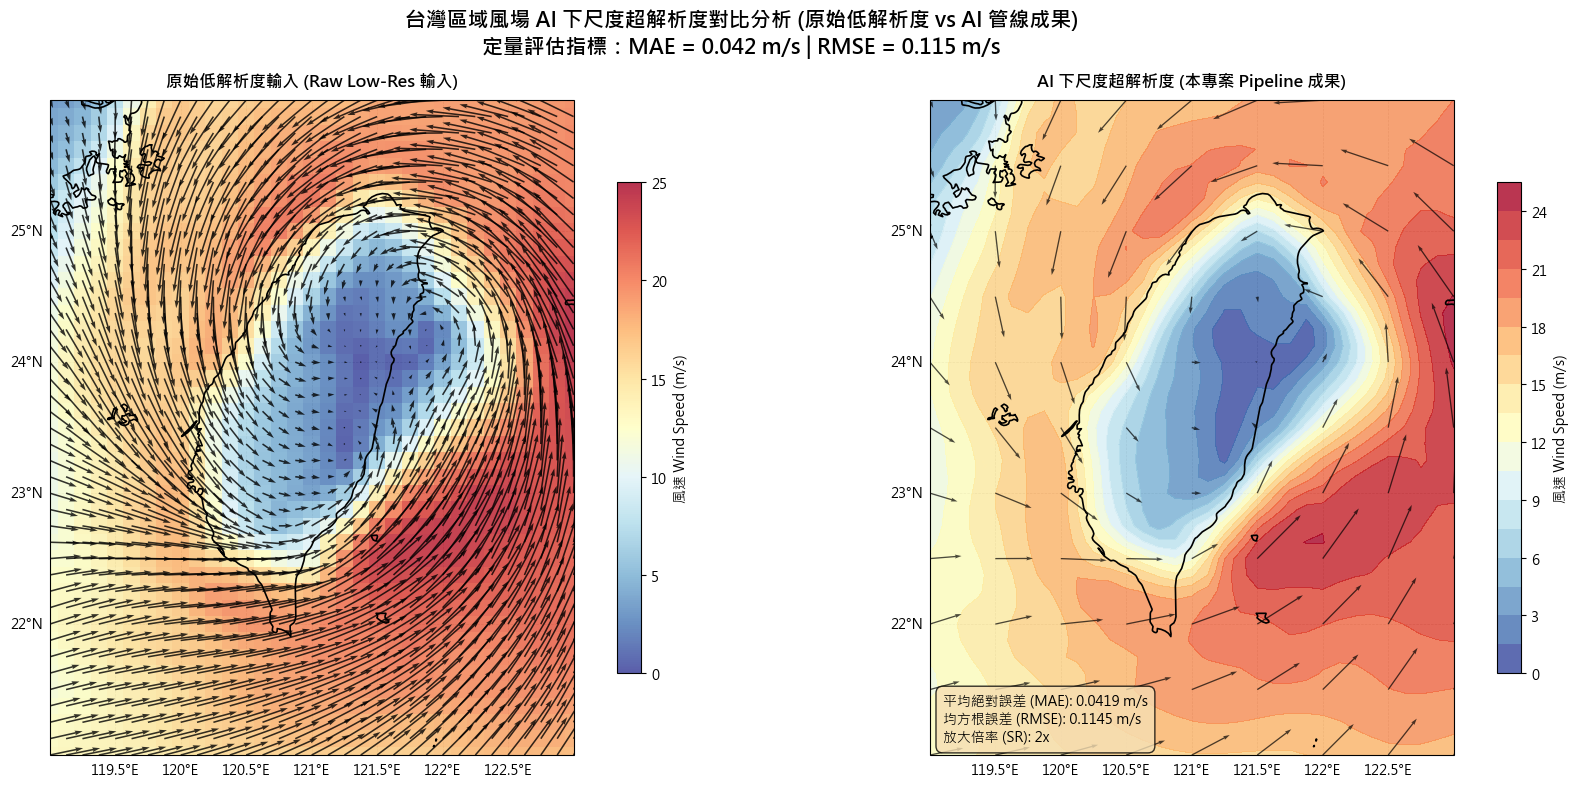

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker

# === 🛠️ 1. 支援繁體中文與負號設定 ===
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'Arial'] # 使用微軟正黑體
plt.rcParams['axes.unicode_minus'] = False # 正常顯示負號

# === 🛠️ 2. 將一維經緯度座標轉換為 2D 網格矩陣 ===
# 這是為了配合 Cartopy 地圖投影以及 pcolormesh 方塊繪圖的必要步驟
lon1_2d, lat1_2d = np.meshgrid(lon1, lat1)

# ========================================================
# 🎨 3. 繪製終極對比圖 (左圖: 純原生低解析度方塊 | 右圖: AI 放大成果)
# ========================================================
# 設定兩個子圖均使用地理投影
fig, axes = plt.subplots(1, 2, figsize=(18, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# 全圖大標題 (繁體中文化，修復亂碼)
plt.suptitle(f"台灣區域風場 AI 下尺度超解析度對比分析 (原始低解析度 vs AI 管線成果)\n定量評估指標：MAE = {ws_mae:.3f} m/s | RMSE = {ws_rmse:.3f} m/s", 
             fontsize=15, fontweight='bold', y=0.98)

# 設定台灣地圖背景與經緯度的輔助函式
def apply_taiwan_map(ax):
    ax.set_extent([119.0, 123.0, 21.0, 26.0], crs=ccrs.PlateCarree())
    # 疊加高解析度海岸線
    ax.coastlines(resolution='10m', color='black', linewidth=1.2, zorder=3)
    # 疊加陸地與海洋背景顏色
    ax.add_feature(cfeature.LAND.with_scale('10m'), facecolor='#f8fafc', zorder=1)
    ax.add_feature(cfeature.OCEAN.with_scale('10m'), facecolor='#f0f9ff', zorder=0)
    
    # 繪製經緯度網格線
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlocator = mticker.FixedLocator([119, 119.5, 120, 120.5, 121, 121.5, 122, 122.5, 123])
    gl.ylocator = mticker.FixedLocator([21, 22, 23, 24, 25, 26])

# ---- 🔴 左欄: 真正原始低解析度資料 (使用 pcolormesh 呈現原汁原味的馬賽克方塊) ----
ax = axes[0]
apply_taiwan_map(ax)

# vmin/vmax 鎖定 0~25，確保左右兩邊顏色對比的科學標準是一致的
# shading='auto' 會讓它呈現無內插的像素大方塊（類似你第三張圖的效果）
cf0 = ax.pcolormesh(lon1_2d, lat1_2d, ws_interp, cmap='RdYlBu_r', vmin=0, vmax=25, alpha=0.8, shading='auto', zorder=2)

# 畫上原始低解析度的風向箭頭 (不進行跳格抽樣，直接顯現原始格點位置與密度)
ax.quiver(lon1_2d, lat1_2d, u_interp, v_interp, 
          color='black', alpha=0.8, scale=200, width=0.003, zorder=4)
ax.set_title('原始低解析度輸入 (Raw Low-Res 輸入)', fontsize=12, fontweight='bold', pad=10)
fig.colorbar(cf0, ax=ax, label='風速 Wind Speed (m/s)', shrink=0.75)


# ---- 🔵 右欄: AI Pipeline 放大兩倍後的超解析度高密度數據 ----
ax = axes[1]
apply_taiwan_map(ax)

# 右邊維持高密度的 contourf 平滑填色，用以突顯 AI 強大的細緻下尺度能力
cf1 = ax.contourf(lon1_2d, lat1_2d, ws_upsc, levels=20, cmap='RdYlBu_r', vmin=0, vmax=25, alpha=0.8, zorder=2)

# 右欄畫放大後的風向箭頭 (進行跳格抽樣，維持高解析度畫面美觀)
skip = max(1, int(len(lat1)/10))
ax.quiver(lon1_2d[::skip, ::skip], lat1_2d[::skip, ::skip], u_upsc[::skip, ::skip], v_upsc[::skip, ::skip], 
          color='black', alpha=0.7, scale=200, width=0.0025, zorder=4)
ax.set_title('AI 下尺度超解析度 (本專案 Pipeline 成果)', fontsize=12, fontweight='bold', pad=10)
fig.colorbar(cf1, ax=ax, label='風速 Wind Speed (m/s)', shrink=0.75)


# ---- 🌟 在右圖左下角放置繁體中文指標數據盒 ----
props = dict(boxstyle='round,pad=0.5', facecolor='wheat', alpha=0.8)
textstr = f"平均絕對誤差 (MAE): {ws_mae:.4f} m/s\n均方根誤差 (RMSE): {ws_rmse:.4f} m/s\n放大倍率 (SR): {sr_factor}x"
ax.text(119.1, 21.1, textstr, transform=ccrs.PlateCarree(), fontsize=10, bbox=props, zorder=5)

plt.tight_layout()

# 保存終極對比成果 (覆蓋原本的檔案)
comparison_png = os.path.join(current_dir, 'pipeline_comparison_with_metrics.png')
fig.savefig(comparison_png, dpi=300, bbox_inches='tight')
print(f'✅ 終極對比圖（左圖原生馬賽克方塊、右圖AI細緻流暢）已成功儲存: {comparison_png}')
plt.show()

## 5) 誤差分布分析

✅ 台灣地圖版誤差分析圖已保存: C:\Users\ruiyu\OneDrive\Desktop\vscode\corrdiff_clone\corrdiff-main\CorrDiff\pipeline_error_analysis_taiwan.png


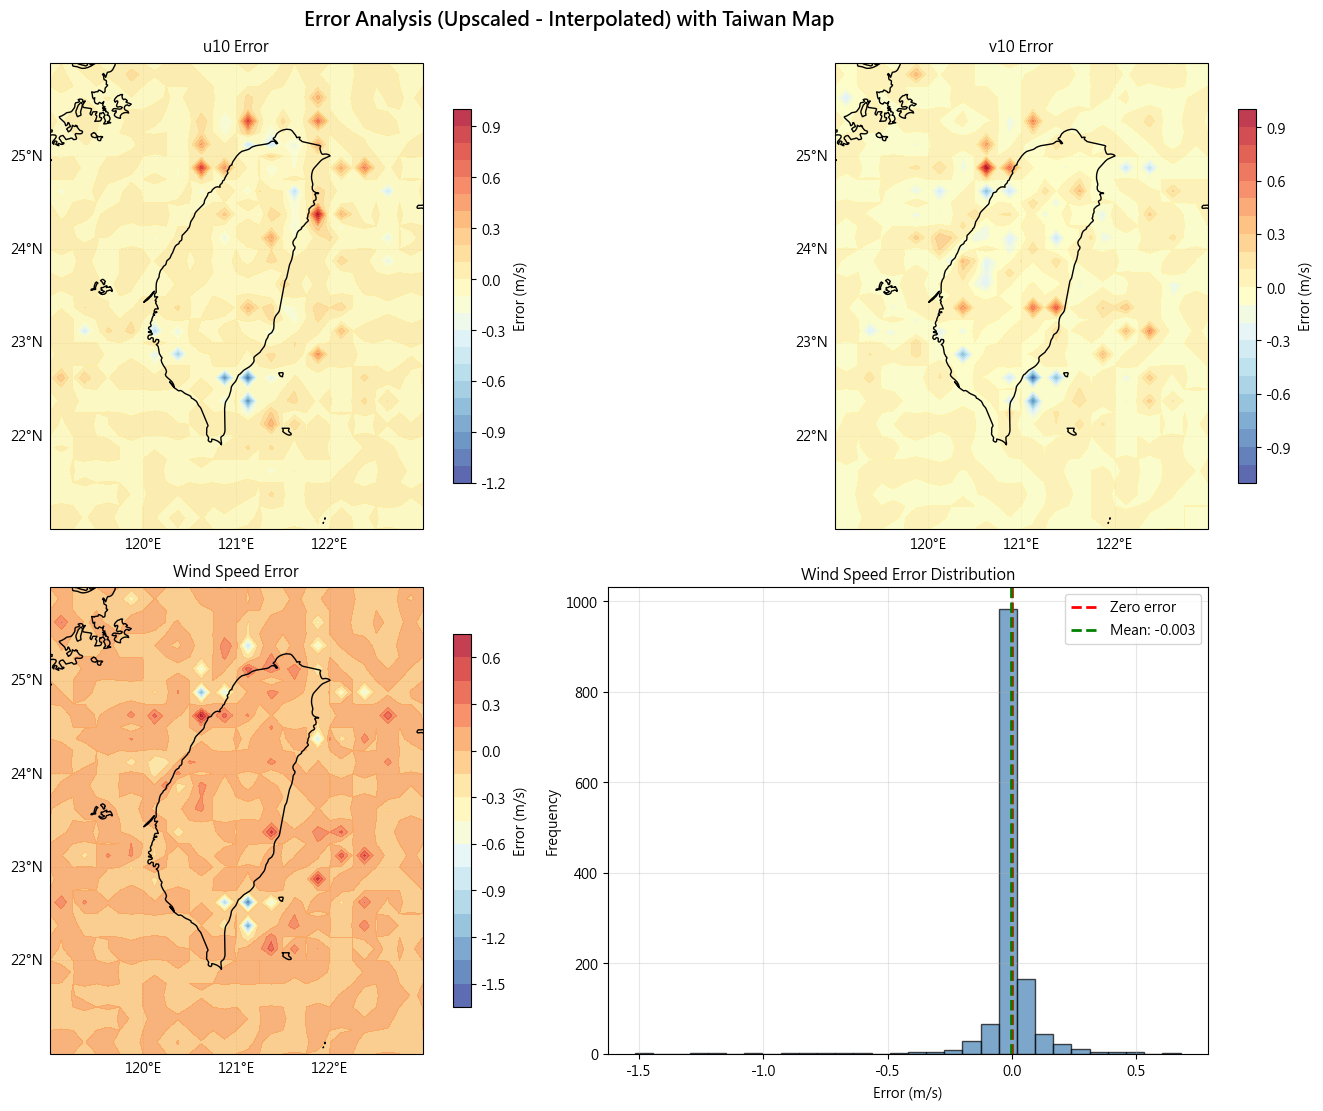


計算統計:
  u10 Error - Mean: -0.0001, Std: 0.0955
  v10 Error - Mean: -0.0000, Std: 0.0925
  Wind Speed Error - Mean: -0.0029, Std: 0.1145


In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker

# 計算誤差場
error_u = u_upsc - u_interp
error_v = v_upsc - v_interp
error_ws = ws_upsc - ws_interp

# 繪製誤差分析圖(2x2) - 這裡設定前三個子圖使用 PlateCarree 地圖投影
fig = plt.figure(figsize=(15, 11), constrained_layout=True)
fig.suptitle('Error Analysis (Upscaled - Interpolated) with Taiwan Map', fontsize=14, fontweight='bold')

# 設定台灣地圖背景的輔助函式
def apply_map_features(ax):
    ax.set_extent([119.0, 123.0, 21.0, 26.0], crs=ccrs.PlateCarree())
    ax.coastlines(resolution='10m', color='black', linewidth=1.0, zorder=3)
    ax.add_feature(cfeature.LAND.with_scale('10m'), facecolor='#f8fafc', zorder=1)
    ax.add_feature(cfeature.OCEAN.with_scale('10m'), facecolor='#f0f9ff', zorder=0)
    
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlocator = mticker.FixedLocator([119, 120, 121, 122, 123])
    gl.ylocator = mticker.FixedLocator([21, 22, 23, 24, 25, 26])

# ---- (0,0) u10 誤差場 ----
ax1 = fig.add_subplot(2, 2, 1, projection=ccrs.PlateCarree())
apply_map_features(ax1)
cf1 = ax1.contourf(lon1, lat1, error_u, levels=20, cmap='RdYlBu_r', alpha=0.8, zorder=2)
ax1.set_title('u10 Error', fontsize=11, pad=8)
fig.colorbar(cf1, ax=ax1, label='Error (m/s)', shrink=0.8)

# ---- (0,1) v10 誤差場 ----
ax2 = fig.add_subplot(2, 2, 2, projection=ccrs.PlateCarree())
apply_map_features(ax2)
cf2 = ax2.contourf(lon1, lat1, error_v, levels=20, cmap='RdYlBu_r', alpha=0.8, zorder=2)
ax2.set_title('v10 Error', fontsize=11, pad=8)
fig.colorbar(cf2, ax=ax2, label='Error (m/s)', shrink=0.8)

# ---- (1,0) 風速誤差場 ----
ax3 = fig.add_subplot(2, 2, 3, projection=ccrs.PlateCarree())
apply_map_features(ax3)
cf3 = ax3.contourf(lon1, lat1, error_ws, levels=20, cmap='RdYlBu_r', alpha=0.8, zorder=2)
ax3.set_title('Wind Speed Error', fontsize=11, pad=8)
fig.colorbar(cf3, ax=ax3, label='Error (m/s)', shrink=0.8)

# ---- (1,1) 誤差統計直方圖 (統計圖保持一般座標軸，不加地圖) ----
ax4 = fig.add_subplot(2, 2, 4)
ax4.hist(error_ws[~np.isnan(error_ws)].ravel(), bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax4.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero error')
ax4.axvline(np.nanmean(error_ws), color='green', linestyle='--', linewidth=2, label=f'Mean: {np.nanmean(error_ws):.3f}')
ax4.set_title('Wind Speed Error Distribution', fontsize=11)
ax4.set_xlabel('Error (m/s)')
ax4.set_ylabel('Frequency')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 保存圖片
error_png = os.path.join(current_dir, 'pipeline_error_analysis_taiwan.png')
fig.savefig(error_png, dpi=200, bbox_inches='tight')
print(f'✅ 台灣地圖版誤差分析圖已保存: {error_png}')
plt.show()

print(f'\n計算統計:')
print(f'  u10 Error - Mean: {np.nanmean(error_u):.4f}, Std: {np.nanstd(error_u):.4f}')
print(f'  v10 Error - Mean: {np.nanmean(error_v):.4f}, Std: {np.nanstd(error_v):.4f}')
print(f'  Wind Speed Error - Mean: {np.nanmean(error_ws):.4f}, Std: {np.nanstd(error_ws):.4f}')

## 6) 模形權重代敢接面說明

在 `CorrDiff/pipeline.py` 中，`ModelWrapper.load_weights(path)` 是後續接入 CorrDiff 實體模形的䦣，當你有CorrDiff 的 package 或 checkpoint，可以在 `load_weights` 實作：

```python
from earth2studio.models.auto.package import Package
from earth2studio.models.dx import CorrDiff

pkg = Package(path_to_package_root)
model = CorrDiff.load_model(pkg, device='cuda:0')
self._model = model
```

`ModelWrapper.predict()` 目前會使用插值函數；未來可修改為呼叫 `self._model(...)` 並轉換強化/輸出格式。

---

## 完成

你現在可以在報告中直接展示 `pipeline_comparison_with_metrics.png` 或 `pipeline_error_analysis.png`，或逛開本筆記本往格執行以示範完整流程。

如要細企（例如加入更練亮的地圖、投影或其他統計計數），次次可以縛筫諸型。

# CorrDiff Pipeline 範例
這個 Notebook 示範如何使用專案內的 `CorrDiff/pipeline.py` 執行一個完整的推論 Pipeline（目前以插值模擬下尺度），並繪製放大前後的對比圖以供簡報展示。

說明：
- 輸入：`corrdiff_output.nc`（粗解析度）
- 放大：插值（cubic）模擬 CorrDiff 行為（可替換為實體模型）
- 輸出：`corrdiff_pipeline_out.nc`（高解析度 NetCDF4）

In [9]:
# 在 Windows 上避免 HOME 相關錯誤
import os
os.environ['HOME'] = os.environ.get('USERPROFILE', '')

# 常用套件與 pipeline 模組
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import CorrDiff.pipeline as pipeline

# 顯示圖表內嵌於 notebook
%matplotlib inline

c:\Users\ruiyu\miniconda3\envs\earth_final\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
c:\Users\ruiyu\miniconda3\envs\earth_final\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.cloud.storage_control_v2 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.storage_control_v2 past that date.
  warnings.warn(message, FutureWarning)


📖 讀取 taiwan_test_data.nc...


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\ruiyu\\OneDrive\\Desktop\\vscode\\corrdiff_clone\\corrdiff-main\\CorrDiff\\taiwan_test_data.nc'

## 1) 執行 Pipeline（會在工作資料夾產生輸出檔案）
你可以修改 `sr_factor` 或 `--weights` 參數（權重為保留介面，目前為 placeholder）。

In [ ]:
# pipeline 執行範例（若已執行過可跳過這格）
input_path = 'corrdiff_output.nc'
output_path = 'corrdiff_pipeline_out.nc'
sr_factor = 2

# 若要指定本地模型權重或 package 路徑，可填 weights 參數
weights = None  # e.g. 'path/to/corrdiff_package'

# 呼叫 pipeline.run_pipeline：會產生輸出 NetCDF 檔案
pipeline.run_pipeline(input_path, output_path, sr_factor=sr_factor, weights=weights)

## 2) 載入放大前 / 放大後資料並繪圖對比
以下會載入原始檔（可能有或沒有 time 維度）以及 pipeline 產出的高解析度檔，並繪製風速等高線與風向箭頭的比較圖。

In [ ]:
# 讀取資料集
ds_orig = xr.open_dataset(input_path)
ds_up = xr.open_dataset(output_path)

# 處理可能的 time 維度（若有就取第一個時間點）
def _get_uv(ds):
    if 'u10' not in ds or 'v10' not in ds:
        raise ValueError('Dataset 必須包含 u10 與 v10 變數')
    if ds['u10'].ndim == 3:
        u = ds['u10'][0].values
        v = ds['v10'][0].values
    else:
        u = ds['u10'].values
        v = ds['v10'].values
    return u, v

u0, v0 = _get_uv(ds_orig)
u1, v1 = _get_uv(ds_up)

# 取得經緯度座標
lat0 = ds_orig['latitude'].values
lon0 = ds_orig['longitude'].values
lat1 = ds_up['latitude'].values
lon1 = ds_up['longitude'].values

# 計算風速
ws0 = np.sqrt(u0**2 + v0**2)
ws1 = np.sqrt(u1**2 + v1**2)

# 繪圖設定
fig, axes = plt.subplots(1, 2, figsize=(14,6), constrained_layout=True)
fig.suptitle(f'原始 (left) vs 放大後 (right) — sr_factor={sr_factor}', fontsize=14)

# 原始分辨率圖
ax = axes[0]
cf = ax.contourf(lon0, lat0, ws0, levels=20, cmap='RdYlBu_r')
ax.quiver(lon0, lat0, u0, v0, scale=200, width=0.0025)
ax.set_title(f'Original: {len(lat0)} x {len(lon0)}')
ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')
plt.colorbar(cf, ax=ax, orientation='vertical', label='Wind Speed (m/s)')

# 放大後圖
ax = axes[1]
skip = max(1, int(len(lat1)/20))
cf = ax.contourf(lon1, lat1, ws1, levels=20, cmap='RdYlBu_r')
ax.quiver(lon1[::skip], lat1[::skip], u1[::skip, ::skip], v1[::skip, ::skip], scale=200, width=0.0025)
ax.set_title(f'Upscaled: {len(lat1)} x {len(lon1)}')
ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')
plt.colorbar(cf, ax=ax, orientation='vertical', label='Wind Speed (m/s)')

# 儲存比較圖供簡報使用
out_fig = 'pipeline_comparison.png'
fig.savefig(out_fig, dpi=150, bbox_inches='tight')
print(f'✅ Saved comparison figure: {out_fig}')
plt.show()

## 3) 權重替換介面說明（給未來 CorrDiff 實體模型）
- 在 `CorrDiff/pipeline.py` 中，`ModelWrapper.load_weights(path)` 是未來接入模型的入口。
- 當你有 CorrDiff 的 package 或 checkpoint，可以在 `load_weights` 實作：
  ```python
  from earth2studio.models.auto.package import Package
  from earth2studio.models.dx import CorrDiff
  pkg = Package(path_to_package_root)
  model = CorrDiff.load_model(pkg, device='cuda:0')
  self._model = model
  ```
- `ModelWrapper.predict()` 目前會呼叫插值函式；未來可改為呼叫 `self._model(...)` 並轉換輸入/輸出格式。

---
完成：你現在可以在報告中直接展示 `pipeline_comparison.png` 或打開本 Notebook 逐格執行以示範完整流程。
若要我把 Notebook 內的圖改成更美觀（地圖底圖、投影等），或加入數值評估指標（MAE、RMSE 等），我可以接著幫你加上。